In [1]:
# install BLADE with !pip install iohblade

from iohblade.loggers import ExperimentLogger
from iohblade.plots import plot_convergence, plot_experiment_CEG, plot_boxplot_fitness_hue
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json


def plot_landscape(row, bounds=(-5, 5), res=200):
    """
    row  : one row of the dataframe (df.loc[idx] or df.iloc[idx])
    bounds: (low, high) tuple applied to both axes
    res   : grid resolution per axis
    """
    # Re-create the callable from the code string
    ns = {}
    exec(row["code"], ns)                      # defines class with same name as row["name"]
    f   = getattr(ns[row["name"]](dim=2), "f")      # instantiate & grab its .f method

    # Grid
    x = np.linspace(bounds[0], bounds[1], res)
    y = np.linspace(bounds[0], bounds[1], res)
    X, Y = np.meshgrid(x, y)
    pts   = np.stack([X.ravel(), Y.ravel()], axis=1)
    Z     = np.apply_along_axis(f, 1, pts).reshape(X.shape)   # robust fallback

    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    cs = ax.contourf(X, Y, Z, levels=50, cmap="viridis")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Landscape of {row['name']}")
    plt.colorbar(cs, ax=ax, label="f(x)")
    plt.tight_layout()
    return fig, ax

logger = ExperimentLogger('../results/ELA_novelty_3_local', True)
# logger.add_read_dir('../results/kerneltuner-o4')
# logger.add_read_dir('../results/kerneltuner-o4-no-info')

/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
methods, problems = logger.get_methods_problems()
print(methods)
print(problems)
len(problems)



['LLaMEA-multi-llm']
['Homogeneous', 'NOT Basins_Separable', 'NOT Basins', 'Multimodality', 'Multimodality_Basins', 'NOT Basins_Multimodality', 'NOT Homogeneous_GlobalLocal', 'GlobalLocal_Basins', 'Basins_Homogeneous', 'Separable_GlobalLocal', 'GlobalLocal_Multimodality', 'NOT Homogeneous', 'Multimodality_Homogeneous', 'NOT Basins_GlobalLocal', 'Separable_Basins', 'NOT Homogeneous_Separable', 'Separable', 'Separable_Homogeneous', 'Basins', 'GlobalLocal', 'NOT Homogeneous_Multimodality', 'Separable_Multimodality', 'GlobalLocal_Homogeneous']


23

Skipped: Problem: Basins, data points: 1
Skipped: Problem: GlobalLocal_Basins, data points: 0
Skipped: Problem: NOT Basins, data points: 1
Skipped: Problem: NOT Basins_Multimodality, data points: 10
Skipped: Problem: Separable_Homogeneous, data points: 0


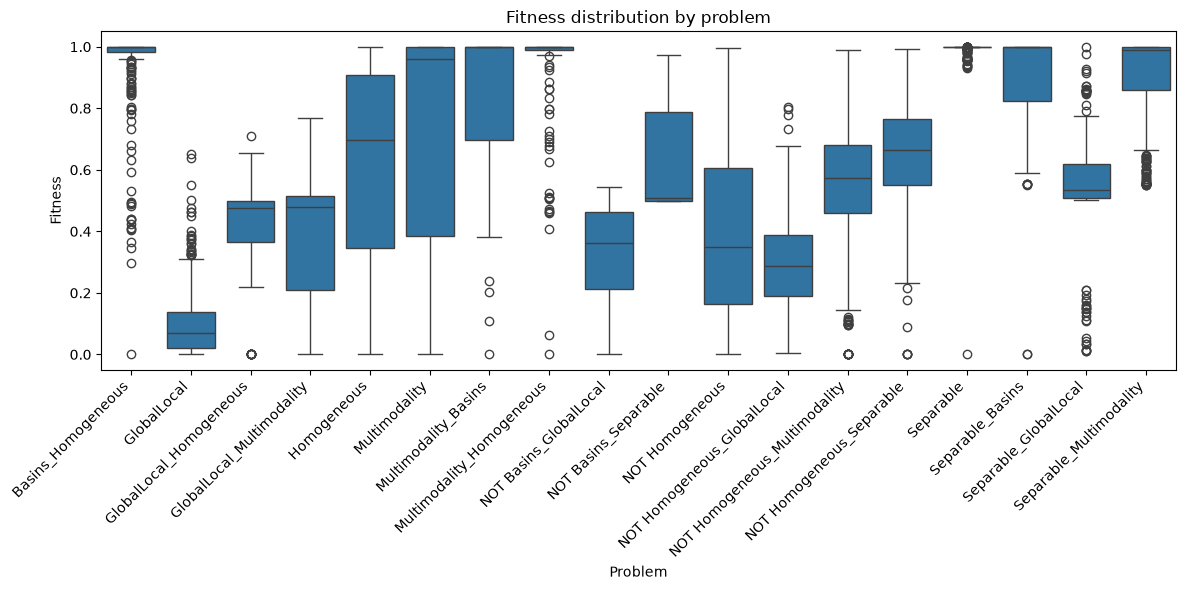

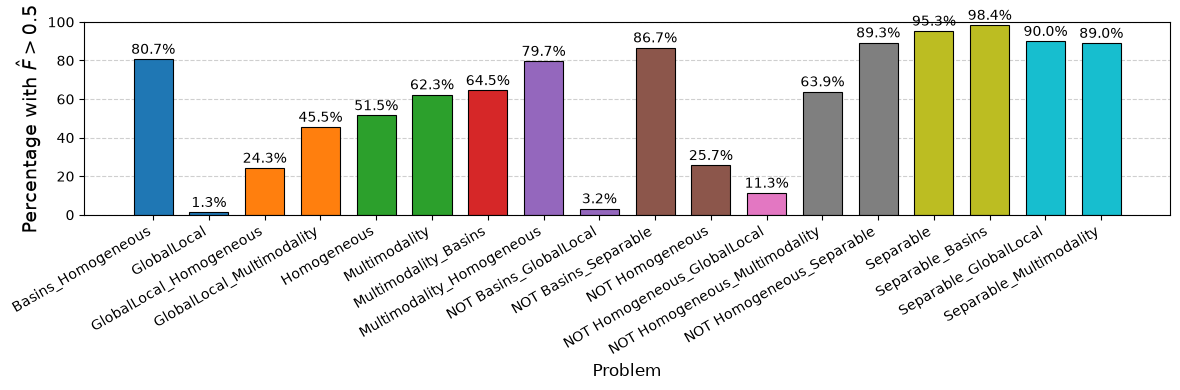

In [3]:
#plot_convergence(logger, metric="fitness", save=False, budget=100)
#plot_boxplot_fitness_hue(logger)

methods, problems = logger.get_methods_problems()
#sort problems by alphabetical order
problems = sorted(problems)

dfs = []
for problem in problems:
    data = logger.get_problem_data(problem_name=problem)
    data = data[data['fitness'] < 1.0001]
    # print if the length of the data is smaller than 11
    if len(data) < 11:
        print(f"Skipped: Problem: {problem}, data points: {len(data)}")
    else:
        data = data.assign(problem_name=str(problem))
        dfs.append(data[["problem_name", "fitness"]])

if len(dfs) > 0:
    all_data = pd.concat(dfs, ignore_index=True)
    problems_to_plot = sorted(all_data['problem_name'].unique())
    ncols = 5
    nrows = int(np.ceil(len(problems_to_plot) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True)
    axes = axes.flatten()

    for ax, problem in zip(axes, problems_to_plot):
        subset = all_data[all_data['problem_name'] == problem]
        if len(subset) == 0:
            ax.axis('off')
            continue
        sns.boxplot(data=subset, y='fitness', ax=ax)
        ax.set_title(problem, fontsize=9)
        ax.set_xlabel('')
        ax.set_xticks([])
        ax.set_ylabel('Fitness')
        ax.set_ylim(all_data['fitness'].min() - 0.05, all_data['fitness'].max() + 0.05)

    for ax in axes[len(problems_to_plot):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # now count the number of landscapes with a fitness above 0.75 per problem and show this as a bar plot
    counts = all_data[all_data['fitness'] > 0.5].groupby('problem_name').size() / all_data.groupby('problem_name').size() * 100  # percentage

    fig, ax = plt.subplots(figsize=(12, 4))

    # Generate colors from a colormap (tab10 has 10 distinct colors)
    colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))

    # Plot bars with reduced width
    bars = ax.bar(counts.index, counts.values, color=colors, width=0.7, edgecolor='black', linewidth=0.8)

    # Add labels and nicer style
    ax.set_xlabel("Problem", fontsize=12)
    ax.set_ylabel("Percentage with $\hat{F} > 0.5$", fontsize=14)
    ax.set_ylim(0, 100)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Rotate and align x labels
    plt.xticks(rotation=30, ha='right')

    # Optionally add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%", ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import joblib

def _plot_on_ax(row, ax, bounds=(-5, 5), res=300):
        ns = {}
        exec(row["code"], ns)
        f = getattr(ns[row["name"]](dim=2), "f")

        x = np.linspace(*bounds, res)
        y = np.linspace(*bounds, res)
        X, Y = np.meshgrid(x, y)
        Z = np.apply_along_axis(f, 1, np.stack([X.ravel(), Y.ravel()], axis=1)).reshape(X.shape)

        cs = ax.contour(X, Y, Z, levels=40, linewidths=0.6)
        #ax.clabel(cs, cs.levels[::2], inline=True, fontsize=6, fmt="%.2g")  # optional labels

        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{row['name']}", fontsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1.0)

def min_intragroup_distances(df, group_col, num_cols):
    """
    For each row, compute the distance to its nearest neighbor *within the same group*.
    Returns a Series aligned to df.index with NaN for groups of size 1.
    """
    X = df[num_cols].astype(float).copy()
    out = pd.Series(np.nan, index=df.index, name="min_intragroup_dist")

    for gval, g in df.groupby(group_col, sort=False):
        Xi = X.loc[g.index].to_numpy()
        n = len(Xi)
        if n < 2:
            continue
        # pairwise Euclidean distances
        dists = pairwise_distances(Xi, metric='cityblock')
        # Set diagonal to np.inf to ignore self-distances
        np.fill_diagonal(dists, np.inf)
        mins = dists.min(axis=1)
        out.loc[g.index] = mins
        # clip outliers
        # out.loc[g.index] = np.clip(out.loc[g.index], 0, 100)
        # make values too close to zero, 0.01
        out.loc[g.index] = np.where(out.loc[g.index] < 0.1, 0.1, out.loc[g.index])

    return out


# Train a standard scaler
if True:
    all_ela_data = []

    for problem in problems:
        data = logger.get_problem_data(problem_name=problem)
        meta_df = pd.json_normalize(data['metadata'])

        expected_len = meta_df["ela_features"].apply(lambda v: len(v) if hasattr(v, '__len__') else 0).mode()[0]
        meta_df = meta_df[meta_df["ela_features"].apply(
            lambda v: hasattr(v, '__len__') and len(v) == expected_len
        )]
        meta_df["ela_features"] = meta_df["ela_features"].apply(
            lambda v: v[0] if isinstance(v, (list, tuple)) and len(v) == 1 else v
        )
        #remove nans and infs
        meta_df = meta_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["ela_features"])

        try:
            ela_mat = np.vstack(meta_df["ela_features"].values)
            all_ela_data.append(ela_mat)
        except Exception as e:
            print(f"Error processing problem {problem}: {e}")
            continue
    # combine into one big matrix
    all_ela_data = np.vstack(all_ela_data)

    # remove inf and NaN
    all_ela_data = np.where(np.isfinite(all_ela_data), all_ela_data, np.nan)
    mask = ~np.isnan(all_ela_data).any(axis=1)
    all_ela_data = all_ela_data[mask]

    # fit one scaler
    scaler = StandardScaler().fit(all_ela_data)
    joblib.dump(scaler, "ela_scaler.joblib")


for problem in problems:
    data = logger.get_problem_data(problem_name=problem)

    # Get feature names from problem name
    feature_names = problem.split("_")[0:2]  # e.g. "basins_separable" -> ["basins", "separable"] and "basins" --> ["basins"]

    try:
        # Filter the best fitness values above 0.75 threshold
        #print(data["fitness"].describe())
        meta_df = pd.json_normalize(data['metadata'])

        if len(feature_names) == 1:
            index_mask = meta_df['score_' + feature_names[0] + '_2D'] > 0.5
        elif len(feature_names) == 2:
            index_mask = (meta_df['score_' + feature_names[0] + '_2D'] > 0.5) & (meta_df['score_' + feature_names[1] + '_2D'] > 0.5)
        else:
            raise ValueError(f"Unexpected number of features in problem name: {problem}")

        df_best = data.loc[index_mask].copy()
        meta_df = meta_df.loc[index_mask].copy()

        #print(meta_df.columns)

        expected_len = meta_df["ela_features"].apply(lambda v: len(v) if hasattr(v, '__len__') else 0).mode()[0]
        meta_df = meta_df[meta_df["ela_features"].apply(
            lambda v: hasattr(v, '__len__') and len(v) == expected_len
        )]

        meta_df["ela_features"] = meta_df["ela_features"].apply(lambda v: v[0] if isinstance(v, (list, tuple)) and len(v)==1 else v)

        # -- explode into separate numeric columns
        ela_mat = np.vstack(meta_df["ela_features"].values)
        ela_cols = [f"ela_{i}" for i in range(ela_mat.shape[1])]
        ela_df   = pd.DataFrame(ela_mat, columns=ela_cols, index=meta_df.index)

        df = pd.concat([df_best, ela_df], axis=1)
        #remove inf values from ela_cols dataframe
        df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=ela_cols)

        #print(df.columns)
        scaler = joblib.load(f"ela_scaler.joblib")

        

        
        #pc = TSNE(n_components=2, learning_rate='auto',
        #              init='random', perplexity=6).fit_transform(X_scaled)

        #filter on method_name
        #df_gpt5 = df[df["method_name"].str.contains("devstral") | df["method_name"].str.contains("qwen")]
        X_scaled = scaler.transform(df[ela_cols])
        pc = PCA(n_components=2).fit_transform(X_scaled)
        fig, ax = plt.subplots(figsize=(12, 8))
        sns.scatterplot(x=pc[:, 0], y=pc[:, 1], hue=df["method_name"], ax=ax, s=20, alpha=0.7) #palette="viridis", 
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        ax.set_title(f"ELA feature PCA for {problem}")
        #plt.colorbar()
        plt.tight_layout()
        plt.show()
        plt.clf()

        #X_scaled = scaler.transform(df[ela_cols])
        pc = TSNE(n_components=2, learning_rate='auto',
                    init='random', perplexity=6).fit_transform(X_scaled)
        fig, ax = plt.subplots(figsize=(12, 8))
        sns.scatterplot(x=pc[:, 0], y=pc[:, 1], hue=df["method_name"], ax=ax, s=20, alpha=0.7) #palette="viridis", 
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        ax.set_title(f"ELA feature TSNE for {problem}")
        #plt.colorbar()
        plt.tight_layout()
        plt.show()
        plt.clf()



        # Now get some numerical diversity metrics on the ELA features per method
        df[ela_cols] = scaler.transform(df[ela_cols])
        min_d = min_intragroup_distances(df, "method_name", ela_cols)
        #print(min_d.head())
        #print(min_d.describe())
        

        
        # Plot: histogram of min distances, colored per group
        plt.figure()
        bins = 100  # tune as needed
        for gval, s in min_d.groupby(df["method_name"]):
            if "qwen" not in gval and "devstral" not in gval:
                continue
            vals = s.dropna().to_numpy()
            if len(vals) == 0:
                continue
            #print(np.max(vals), "max ela dist", str(gval))
            sns.histplot(vals, bins=bins, log_scale=True, alpha=0.3, label=str(gval), kde=True, stat="density")  # kde=True adds a kernel density estimate
            #plt.hist(vals, bins=bins, alpha=0.5, label=str(gval), density=True)  # density normalizes for different group sizes
        plt.xlabel(f"Nearest-neighbor distance within group for {problem}")
        plt.ylabel("Density")
        plt.xlim(0, 100)
        plt.ylim(0, 3.5)
        plt.legend(title="Method")
        plt.tight_layout()
        plt.show()


        # Plot: histogram of min distances, colored per group
        plt.figure()
        bins = 100  # tune as needed
        for gval, s in min_d.groupby(df["method_name"]):
            if "gpt" not in gval and "qwen3.5" not in gval:
                continue
            vals = s.dropna().to_numpy()
            if len(vals) == 0:
                continue
            #print(np.max(vals), "max ela dist", str(gval))
            sns.histplot(vals, bins=bins, log_scale=True, alpha=0.3, label=str(gval), kde=True, stat="density")  # kde=True adds a kernel density estimate
            #plt.hist(vals, bins=bins, alpha=0.5, label=str(gval), density=True)  # density normalizes for different group sizes
        plt.xlabel(f"Nearest-neighbor distance within group for {problem}")
        plt.ylabel("Density")
        plt.xlim(0, 100)
        plt.ylim(0, 3.5)
        plt.legend(title="Method")
        plt.tight_layout()
        plt.show()

        from scipy.stats import gaussian_kde
        from scipy.integrate import quad
        # Plot: histogram of min distances, colored per group for devstral
        plt.figure()
        bins = 100  # tune as needed
        kde_results = {}
        for gval, s in min_d.groupby(df["method_name"]):
            # if "devstral" not in gval:
            #     continue
            vals = s.dropna().to_numpy()
            if len(vals) == 0:
                continue

            # Fit KDE
            
            kde = gaussian_kde(vals)

            # KDE-weighted mean: integral of x * kde(x) over [0, 100]
            weighted_mean = quad(lambda x: x * kde(x), 0, 100)[0]

            kde_results[gval] = weighted_mean
            #print(np.max(vals), "max ela dist", str(gval))
            #sns.histplot(vals, bins=bins, log_scale=True, alpha=0.05, label=str(gval), kde=True, stat="density")  # kde=True adds a kernel density estimate
            sns.kdeplot(vals, log_scale=True, label=str(gval))
            #plt.hist(vals, bins=bins, alpha=0.5, label=str(gval), density=True)  # density normalizes for different group sizes
        plt.xlabel(f"Nearest-neighbor distance within group for {problem}")
        plt.xlim(0, 100)
        plt.ylim(0, 3.5)
        plt.ylabel("Density")
        plt.legend(title="Method")
        plt.tight_layout()
        plt.show()

        from IPython.display import display

        df_kde = pd.DataFrame.from_dict(kde_results, orient="index", columns=["KDE Weighted Mean [0,100]"])
        df_kde.index.name = "Method"
        df_kde = df_kde.sort_values("KDE Weighted Mean [0,100]", ascending=False)
        display(df_kde.style.format({"KDE Weighted Mean [0,100]": "{:.4f}"}))





        # Now for each method, for the landscapes with the highest ela distance, plot the landscape using plot_landscape
        # attach distances to df for convenience
        df2 = df.copy()
        df2["min_intragroup_dist"] = min_d

        if False: #plot landscapes

            for method, grp in df2.groupby("method_name", sort=False):
                top = grp.nlargest(36, "min_intragroup_dist")  # preserves original df index
                #print(method, top[["min_intragroup_dist"]])

                try:
                    rows, cols = 6, 6
                    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows), dpi=300)

                    for ax in axes.ravel():
                        ax.axis("off")           # blank everything first

                    for ax, (_, row) in zip(axes.ravel(), top.iterrows()):
                        _plot_on_ax(row, ax, bounds=(-5, 5), res=200)

                    fig.suptitle(f"Most seperate landscapes {problem} for {method}")
                    plt.tight_layout()
                    plt.show()
                    plt.savefig(f"landscapes_{problem}_{method}.pdf")
                    plt.clf()
                except Exception as e:
                    print(f"plot failed: {e}")

    except Exception as e:
        print(f"Failed on problem {problem}: {e}")  